<a href="https://colab.research.google.com/github/memo124/Pr-ctica-de-Redes-Neuronales-Dise-o-de-Arquitecturas-Densas/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Redes Neuronales: Diseño de Arquitecturas Densas

## Equipo y roles

- **Guillermo Andres Minero Alfaro:** Especialista en Datos y Arquitecto de los modelos A y B.
- **Ruben Armando Vigil Mejia:** Arquitecto del modelo C y Analista de Métricas.

En esta primera parte preparamos los datos y comparamos una red minimalista con una red profunda.

## 1. Preparación de los datos

Usaremos el dataset de cáncer de mama incluido en Scikit-learn. Es un problema de clasificación binaria. Los datos se separan en entrenamiento, validación y prueba. El conjunto de prueba se reserva para el final.

In [1]:
%matplotlib inline

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Semillas para poder repetir el experimento.
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Cargar el dataset.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Separar primero el 20 % para la prueba final.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Separar una parte del entrenamiento para validación.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Ajustar el escalador solo con los datos de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Dataset completo: {X.shape}')
print(f'Entrenamiento: {X_train_scaled.shape}')
print(f'Validación: {X_val_scaled.shape}')
print(f'Prueba: {X_test_scaled.shape}')

Dataset completo: (569, 30)
Entrenamiento: (364, 30)
Validación: (91, 30)
Prueba: (114, 30)


## 2. Modelo A: El Minimalista

Tiene una sola capa oculta de 8 neuronas. ReLU ayuda a aprender relaciones no lineales y Sigmoid entrega una probabilidad entre 0 y 1 para la clasificación binaria. Este modelo sirve como punto de comparación sencillo.

In [2]:
model_A = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_A.summary()
history_A = model_A.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=32, verbose=0
)
print('Modelo A entrenado correctamente.')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo A entrenado correctamente.


## 3. Modelo B: El Profundo

Tiene tres capas ocultas de 64, 128 y 64 neuronas. Su mayor cantidad de neuronas le permite aprender patrones más complejos, pero también aumenta el riesgo de memorizar los datos de entrenamiento y presentar overfitting.

In [3]:
model_B = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_B.summary()
history_B = model_B.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150, batch_size=32, verbose=0
)
print('Modelo B entrenado correctamente.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,625 (72.75 KB)

 Trainable params: 18,625 (72.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo B entrenado correctamente.


## 4. Curvas de aprendizaje

La línea vertical marca la época con el menor `val_loss`. Después de ese punto puede aparecer overfitting si el error de entrenamiento sigue bajando mientras el error de validación aumenta.

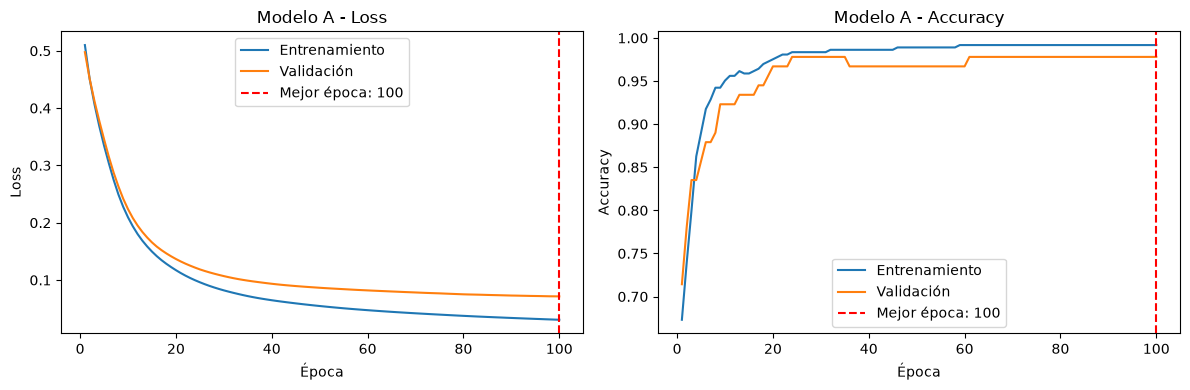

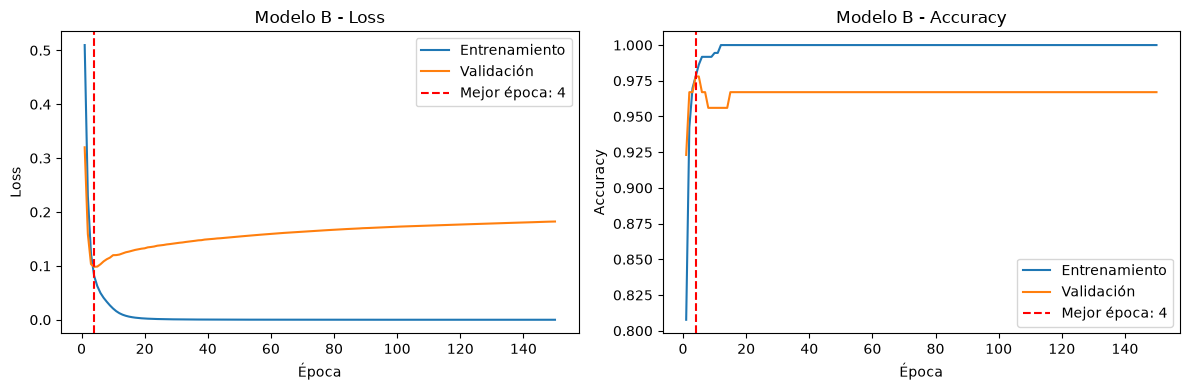

Mejor época del Modelo A según val_loss: 100
Mejor época del Modelo B según val_loss: 4


In [4]:
def plot_history(history, model_name):
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    epochs = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history.history['loss'], label='Entrenamiento')
    axes[0].plot(epochs, history.history['val_loss'], label='Validación')
    axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history.history['accuracy'], label='Entrenamiento')
    axes[1].plot(epochs, history.history['val_accuracy'], label='Validación')
    axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return best_epoch

best_epoch_A = plot_history(history_A, 'Modelo A')
best_epoch_B = plot_history(history_B, 'Modelo B')
print(f'Mejor época del Modelo A según val_loss: {best_epoch_A}')
print(f'Mejor época del Modelo B según val_loss: {best_epoch_B}')

## 5. Evaluación final de los modelos A y B

Ahora usamos por primera vez el conjunto de prueba. Esto permite medir el rendimiento con datos que no participaron en el entrenamiento ni en la selección visual de la mejor época.

In [5]:
test_loss_A, test_accuracy_A = model_A.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_B, test_accuracy_B = model_B.evaluate(X_test_scaled, y_test, verbose=0)

results = pd.DataFrame({
    'Modelo': ['A - Minimalista', 'B - Profundo'],
    'Mejor época (val_loss)': [best_epoch_A, best_epoch_B],
    'Test Loss': [test_loss_A, test_loss_B],
    'Test Accuracy': [test_accuracy_A, test_accuracy_B]
})
display(results.round(4))

,Modelo,Mejor época (val_loss),Test Loss,Test Accuracy
0,A - Minimalista,100,0.0861,0.9561
1,B - Profundo,4,0.2042,0.9561


## 6. Análisis de overfitting

In [6]:
winner = 'Modelo A' if test_accuracy_A >= test_accuracy_B else 'Modelo B'
analysis = f'''
- En el **Modelo A**, el menor `val_loss` se obtuvo en la época **{best_epoch_A}**.
- En el **Modelo B**, el menor `val_loss` se obtuvo en la época **{best_epoch_B}**. Después de esta época, una separación creciente entre entrenamiento y validación indica overfitting.
- El Modelo B tiene mayor capacidad y puede memorizar con más facilidad un dataset pequeño.
- En la prueba final, el Modelo A obtuvo **{test_accuracy_A:.2%}** de accuracy y el Modelo B obtuvo **{test_accuracy_B:.2%}**.
- Según el accuracy de prueba de esta ejecución, **{winner}** consiguió el mejor resultado. También deben revisarse las curvas de loss y la diferencia entre entrenamiento y validación.

No usamos `EarlyStopping` en estos dos modelos porque queremos observar el overfitting. Esa técnica se aplicará en el Modelo C.
'''
display(Markdown(analysis))


- En el **Modelo A**, el menor `val_loss` se obtuvo en la época **100**.
- En el **Modelo B**, el menor `val_loss` se obtuvo en la época **4**. Después de esta época, una separación creciente entre entrenamiento y validación indica overfitting.
- El Modelo B tiene mayor capacidad y puede memorizar con más facilidad un dataset pequeño.
- En la prueba final, el Modelo A obtuvo **95.61%** de accuracy y el Modelo B obtuvo **95.61%**.
- Según el accuracy de prueba de esta ejecución, **Modelo A** consiguió el mejor resultado. También deben revisarse las curvas de loss y la diferencia entre entrenamiento y validación.

No usamos `EarlyStopping` en estos dos modelos porque queremos observar el overfitting. Esa técnica se aplicará en el Modelo C.


---
## 7. Modelo C: El Optimizado

El Modelo C usa dos capas ocultas con ReLU. Agregamos **Dropout** para apagar algunas neuronas durante el entrenamiento y regularización **L2** para evitar pesos demasiado grandes. También usamos Adam y EarlyStopping para detener el entrenamiento cuando `val_loss` deja de mejorar.

In [7]:
model_C = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.30),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.30),
    Dense(1, activation='sigmoid')
])

model_C.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_C.summary()
history_C = model_C.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
print(f'Modelo C entrenado en {len(history_C.history["loss"])} épocas.')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo C entrenado en 41 épocas.


## 8. Curvas del Modelo C

Usamos la misma función de gráficas para comparar entrenamiento y validación. EarlyStopping conserva los pesos de la mejor época.

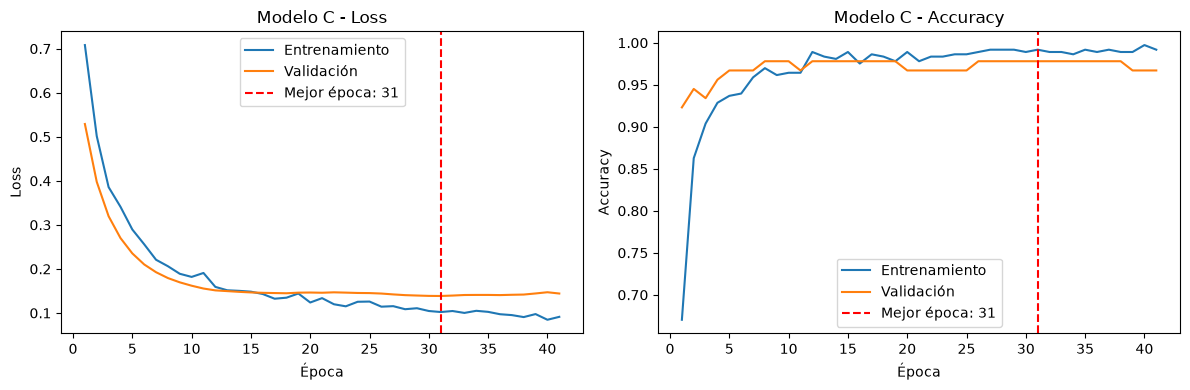

Mejor época del Modelo C según val_loss: 31
EarlyStopping detuvo el entrenamiento después de 41 épocas.


In [8]:
best_epoch_C = plot_history(history_C, 'Modelo C')
epochs_C = len(history_C.history['loss'])
print(f'Mejor época del Modelo C según val_loss: {best_epoch_C}')
print(f'EarlyStopping detuvo el entrenamiento después de {epochs_C} épocas.')

## 9. Comparación final de los tres modelos

In [9]:
test_loss_C, test_accuracy_C = model_C.evaluate(X_test_scaled, y_test, verbose=0)

final_results = pd.DataFrame({
    'Modelo': ['A - Minimalista', 'B - Profundo', 'C - Optimizado'],
    'Épocas entrenadas': [len(history_A.history['loss']), len(history_B.history['loss']), epochs_C],
    'Mejor época (val_loss)': [best_epoch_A, best_epoch_B, best_epoch_C],
    'Test Loss': [test_loss_A, test_loss_B, test_loss_C],
    'Test Accuracy': [test_accuracy_A, test_accuracy_B, test_accuracy_C]
})
display(final_results.round(4))

,Modelo,Épocas entrenadas,Mejor época (val_loss),Test Loss,Test Accuracy
0,A - Minimalista,100,100,0.0861,0.9561
1,B - Profundo,150,4,0.2042,0.9561
2,C - Optimizado,41,31,0.1572,0.9737


## 10. Mesa de auditoría y conclusiones

In [10]:
max_accuracy = final_results['Test Accuracy'].max()
top_models = final_results[np.isclose(final_results['Test Accuracy'], max_accuracy)]
best_model = top_models.loc[top_models['Test Loss'].idxmin()]

if len(top_models) > 1:
    tied_names = ' y '.join(top_models['Modelo'])
    winner_text = (
        f'{tied_names} empataron con el mayor accuracy. ' 
        f'Como desempate, {best_model["Modelo"]} obtuvo el menor test loss.'
    )
else:
    winner_text = f'{best_model["Modelo"]} obtuvo el mayor accuracy de prueba.'

final_analysis = f'''
### Análisis crítico

1. **Funciones de activación:** ReLU permite que las capas ocultas aprendan relaciones no lineales de forma sencilla. Sigmoid es apropiada en la salida porque este problema tiene dos clases y devuelve una probabilidad entre 0 y 1.
2. **Overfitting:** El Modelo A presentó una separación pequeña entre entrenamiento y validación. El Modelo B comenzó a sobreajustarse aproximadamente después de la época **{best_epoch_B}**: su loss de entrenamiento siguió bajando mientras el de validación aumentó.
3. **Modelo optimizado:** Dropout y L2 limitaron la memorización del Modelo C. Su mejor `val_loss` apareció en la época **{best_epoch_C}**.
4. **EarlyStopping:** Detuvo el Modelo C después de **{epochs_C} épocas** y restauró los pesos de la mejor época. Así evitó continuar entrenando sin mejorar la validación.
5. **Resultados de prueba:** A = **{test_accuracy_A:.2%}**, B = **{test_accuracy_B:.2%}** y C = **{test_accuracy_C:.2%}** de accuracy.
6. **Arquitectura ganadora:** {winner_text}

Una red más grande no garantiza una mejor generalización. En un dataset pequeño, también debemos considerar el loss, la estabilidad de las curvas y el overfitting.
'''
display(Markdown(final_analysis))


### Análisis crítico

1. **Funciones de activación:** ReLU permite que las capas ocultas aprendan relaciones no lineales de forma sencilla. Sigmoid es apropiada en la salida porque este problema tiene dos clases y devuelve una probabilidad entre 0 y 1.
2. **Overfitting:** El Modelo A presentó una separación pequeña entre entrenamiento y validación. El Modelo B comenzó a sobreajustarse aproximadamente después de la época **4**: su loss de entrenamiento siguió bajando mientras el de validación aumentó.
3. **Modelo optimizado:** Dropout y L2 limitaron la memorización del Modelo C. Su mejor `val_loss` apareció en la época **31**.
4. **EarlyStopping:** Detuvo el Modelo C después de **41 épocas** y restauró los pesos de la mejor época. Así evitó continuar entrenando sin mejorar la validación.
5. **Resultados de prueba:** A = **95.61%**, B = **95.61%** y C = **97.37%** de accuracy.
6. **Arquitectura ganadora:** C - Optimizado obtuvo el mayor accuracy de prueba.

Una red más grande no garantiza una mejor generalización. En un dataset pequeño, también debemos considerar el loss, la estabilidad de las curvas y el overfitting.
